In [82]:
import pandas as pd	
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.modeling import models, fitting
fitter = fitting.LinearLSQFitter()
from scipy.ndimage import median_filter
from tqdm import tqdm
from random import gauss
from scipy.interpolate import interp1d

In [83]:
standard2MASS=pd.read_csv("../Photometry/2MassStandartStars.csv")
standard2MASS

,Star,HST,RA,DEC,J,Unc_J,H,Unc_H,K,Unc_K,Ks,Unc_Ks
0,9101,P525-E,00:24:28.3,07:49:02,11.622,0.005,11.298,0.005,11.223,0.008,11.223,0.005
1,9103,S294-D,00:33:15.2,-39:24:10,10.932,0.006,10.657,0.004,10.596,0.005,10.594,0.004
2,9104,S754-C,01:03:15.8,-04:20:44,11.045,0.005,10.750,0.005,10.693,0.010,10.695,0.005
3,9105,P530-D,02:33:32.1,06:25:38,11.309,0.010,10.975,0.006,10.897,0.006,10.910,0.005
4,9106,S301-D,03:26:53.9,-39:50:38,12.153,0.007,11.842,0.005,11.772,0.010,11.788,0.006
...,...,...,...,...,...,...,...,...,...,...,...,...
59,9183,P576-F,20:52:47.3,06:40:05,12.247,0.004,11.940,0.004,11.873,0.007,11.880,0.005
60,9185,S889-E,22:02:05.7,-01:06:02,12.021,0.005,11.662,0.004,11.586,0.012,11.585,0.005
61,9186,S893-D,23:18:10.0,00:32:56,11.403,0.009,11.120,0.006,11.045,0.006,11.055,0.006
62,9187,S677-D,23:23:34.4,-15:21:07,11.857,0.003,11.596,0.003,11.538,0.009,11.542,0.003


In [85]:
standard2MASS = standard2MASS.dropna(subset=['J',"H","Ks"]).copy()



In [86]:
standard2MASS["J-H"] = standard2MASS["J"]-standard2MASS['H']
standard2MASS["H-Ks"] = standard2MASS['H']-standard2MASS['Ks']
standard2MASS["J-Ks"] = standard2MASS['J']-standard2MASS['Ks']

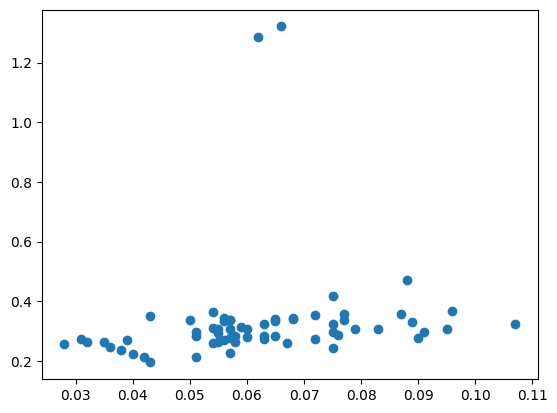

In [87]:
# Cálculo de colores
standard2MASS["J-H"] = standard2MASS["J"] - standard2MASS["H"]
standard2MASS["H-Ks"] = standard2MASS["H"] - standard2MASS["Ks"]
standard2MASS["J-Ks"] = standard2MASS["J"] - standard2MASS["Ks"]
plt.scatter(standard2MASS["H-Ks"],standard2MASS["J-H"])

In [90]:
B1032MASS = pd.read_csv("../Spectra/B103.csv")
B0812MASS = pd.read_csv("../Spectra/B081.csv")
B0492MASS = pd.read_csv("../Spectra/B049.csv")
B1032MASS

,ra,dec,err_maj,err_min,err_ang,designation,j_m,j_cmsig,j_msigcom,j_snr,...,bl_flg,cc_flg,ndet,gal_contam,mp_flg,dist,angle,j_h,h_k,j_k
0,13.768903,-72.777061,0.09,0.07,2,00550453-7246374,14.518,0.03,0.032,56.3,...,111,0,662604,0,0,0.127062,208.564946,-0.052,-0.01,-0.062


In [91]:
star1 = B1032MASS.iloc[[0]]
star2 = B0812MASS.iloc[[0]]
star3 = B0492MASS.iloc[[2]]
stars = pd.concat([star1, star2, star3], ignore_index=True)
stars.to_csv("stars.csv", index=False)

In [92]:
stars

,ra,dec,err_maj,err_min,err_ang,designation,j_m,j_cmsig,j_msigcom,j_snr,...,bl_flg,cc_flg,ndet,gal_contam,mp_flg,dist,angle,j_h,h_k,j_k
0,13.768903,-72.777061,0.09,0.07,2,00550453-7246374,14.518,0.030,0.032,56.3,...,111,0,662604,0,0,0.127062,208.564946,-0.052,-0.01,-0.062
1,13.025198,-72.869232,0.09,0.08,176,00520604-7252092,15.564,0.058,0.059,20.7,...,111,0,560606,0,0,0.547348,181.332129,0.250,0.14,0.390
2,12.425783,-73.286644,0.27,0.23,80,00494218-7317119,16.524,0.234,0.235,8.6,...,100,c00,50000,0,0,6.271406,337.204109,NaN,NaN,NaN


0   -0.052
Name: J-H, dtype: float64 0   -0.01
Name: H-Ks, dtype: float64
1    0.25
Name: J-H, dtype: float64 1    0.14
Name: H-Ks, dtype: float64


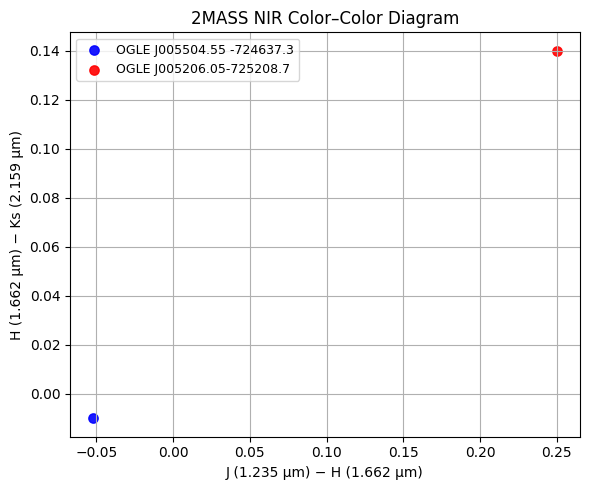

0   -0.062
Name: J-Ks, dtype: float64 0    14.518
Name: j_m, dtype: float64
1    0.39
Name: J-Ks, dtype: float64 1    15.564
Name: j_m, dtype: float64


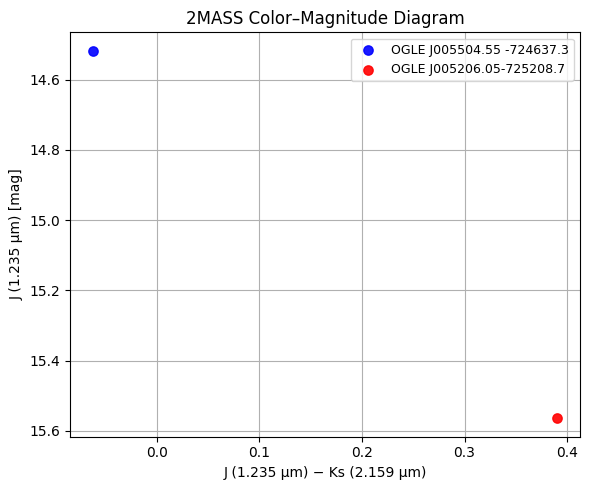

In [93]:
# Filter valid photometry
stars = stars.dropna(subset=["j_m", "h_k", "j_h", "j_k"]).copy()

# Compute colors
stars["J-H"] = stars["j_h"]
stars["H-Ks"] = stars["h_k"]
stars["J-Ks"] = stars["j_k"]

unique_stars = stars["designation"].unique()

star_name_map = {unique_stars[0]: "OGLE J005504.55 -724637.3",unique_stars[1]: "OGLE J005206.05-725208.7"}

color_map = {"OGLE J005504.55 -724637.3": "blue","OGLE J005206.05-725208.7": "red"}

# ----- Color–Color Diagram -----
plt.figure(figsize=(6,5))

for original_name in unique_stars:
    plot_name = star_name_map[original_name]
    subset = stars[stars["designation"] == original_name]
    plt.scatter(subset["J-H"], subset["H-Ks"], s=45, alpha=0.9,
                label=plot_name, color=color_map[plot_name])
    print(subset["J-H"], subset["H-Ks"])

plt.xlabel("J (1.235 μm) − H (1.662 μm)")
plt.ylabel("H (1.662 μm) − Ks (2.159 μm)")
plt.title("2MASS NIR Color–Color Diagram")
plt.grid(True)
plt.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig('phtom2MASScolHK_JH.png')
plt.show()

# ----- Color–Magnitude Diagram (CMD) -----
plt.figure(figsize=(6,5))

for original_name in unique_stars:
    plot_name = star_name_map[original_name]
    subset = stars[stars["designation"] == original_name]
    plt.scatter(subset["J-Ks"], subset["j_m"], s=45, alpha=0.9,
                label=plot_name, color=color_map[plot_name])
    print(subset["J-Ks"], subset["j_m"])

plt.xlabel("J (1.235 μm) − Ks (2.159 μm)")
plt.ylabel("J (1.235 μm) [mag]")
plt.title("2MASS Color–Magnitude Diagram")
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig('phtom2MASSmag.png')
plt.show()

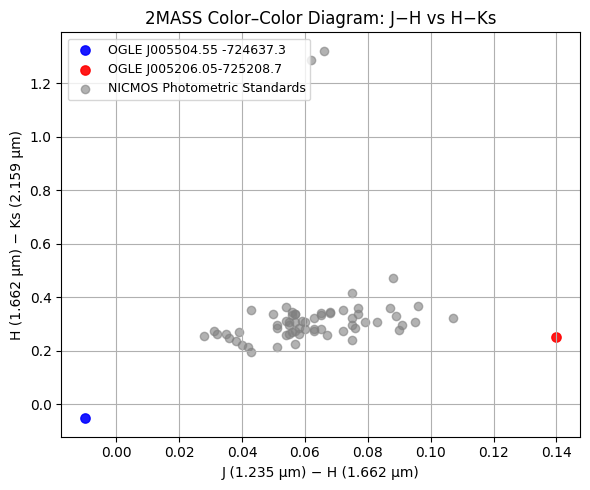

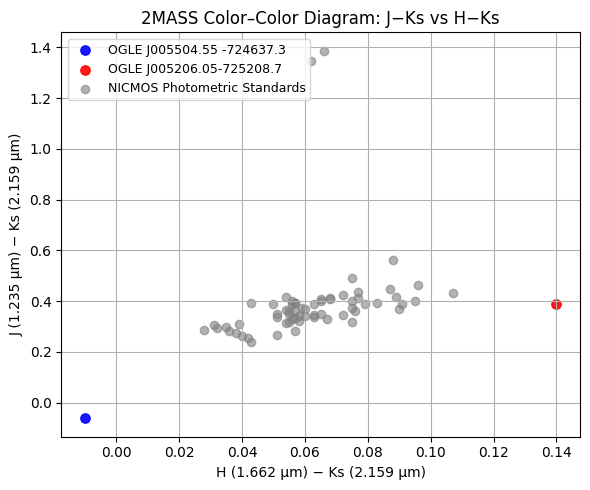

In [101]:
# ----- Color–Color Diagram 1: (J-H) vs (H-Ks) -----
plt.figure(figsize=(6,5))

for original_name in unique_stars:
    plot_name = star_name_map[original_name]
    subset = stars[stars["designation"] == original_name]
    plt.scatter(subset["H-Ks"], subset["J-H"], s=45, alpha=0.9,
                label=plot_name, color=color_map[plot_name])
plt.scatter(standard2MASS["H-Ks"],standard2MASS["J-H"], color='gray',alpha=0.6, label='NICMOS Photometric Standards')
plt.xlabel("J (1.235 μm) − H (1.662 μm)")
plt.ylabel("H (1.662 μm) − Ks (2.159 μm)")
plt.title("2MASS Color–Color Diagram: J−H vs H−Ks")
plt.grid(True)
plt.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("2MASS_CC_JH_HKs.png", dpi=300)
plt.show()


# ----- Color–Color Diagram 2: (J-Ks) vs (H-Ks) -----
plt.figure(figsize=(6,5))

for original_name in unique_stars:
    plot_name = star_name_map[original_name]
    subset = stars[stars["designation"] == original_name]
    plt.scatter(subset["H-Ks"], subset["J-Ks"], s=45, alpha=0.9,
                label=plot_name, color=color_map[plot_name])
plt.scatter(standard2MASS["H-Ks"],standard2MASS["J-Ks"], color='gray',alpha=0.6, label='NICMOS Photometric Standards')


plt.xlabel("H (1.662 μm) − Ks (2.159 μm)")
plt.ylabel("J (1.235 μm) − Ks (2.159 μm)")
plt.title("2MASS Color–Color Diagram: J−Ks vs H−Ks")
plt.grid(True)
plt.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("2MASS_CC_HKs_JKs.png", dpi=300)
plt.show()


In [103]:
standardWISE=pd.read_csv("../Photometry/WISE_Be_synthetic_80stars.csv")
standardWISE

,W1-W2,W2-W3,W3-W4
0,0.424179,0.868197,0.512659
1,0.265434,1.214268,1.393542
2,0.461922,1.886736,1.579298
3,0.680757,0.689038,0.589659
4,0.241462,0.514904,1.481688
...,...,...,...
75,0.505476,0.571389,1.316960
76,0.321762,2.119465,-0.012571
77,0.225248,1.284300,1.093227
78,0.322940,0.285218,0.669107


In [41]:
B081WISE = pd.read_csv("../Spectra/B081WISE.csv")
B049WISE = pd.read_csv("../Spectra/B049WISE.csv")

In [42]:
star2W = B081WISE.iloc[[0]]
star3W = B049WISE.iloc[[0]]
starsW = pd.concat([star2W, star3W], ignore_index=True)
starsW.to_csv("starsW.csv", index=False)
starsW

,designation,ra,dec,sigra,sigdec,sigradec,w1mpro,w1sigmpro,w1snr,w1rchi2,...,w1nm,w1m,w2nm,w2m,w3nm,w3m,w4nm,w4m,dist,angle
0,J005206.90-725216.5,13.028763,-72.871252,0.0656,0.0641,-0.0040,14.335,0.029,37.5,3.358,...,47,47,47,47,0,20,0,20,8.680246,154.276592
1,J004942.22-731719.3,12.425943,-73.288700,0.0419,0.0426,0.0081,12.637,0.024,45.8,3.791,...,50,50,50,50,4,22,5,23,2.782571,234.439411


0    0
Name: W1-W2, dtype: int64 0    27
Name: W2-W3, dtype: int64
1    0
Name: W1-W2, dtype: int64 1    28
Name: W2-W3, dtype: int64


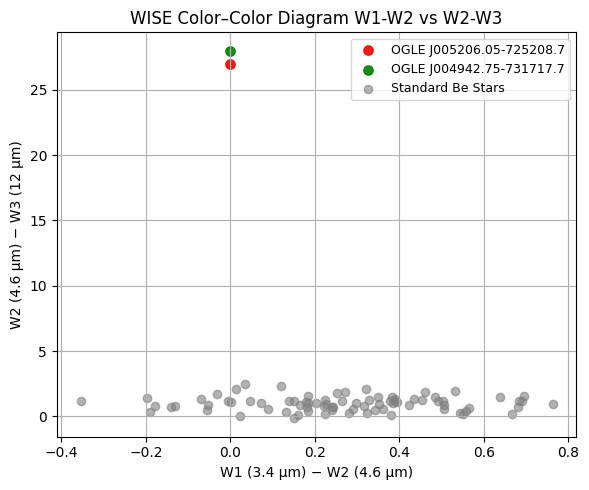

0    27
Name: W2-W3, dtype: int64 0    0
Name: W3-W4, dtype: int64
1    28
Name: W2-W3, dtype: int64 1   -1
Name: W3-W4, dtype: int64


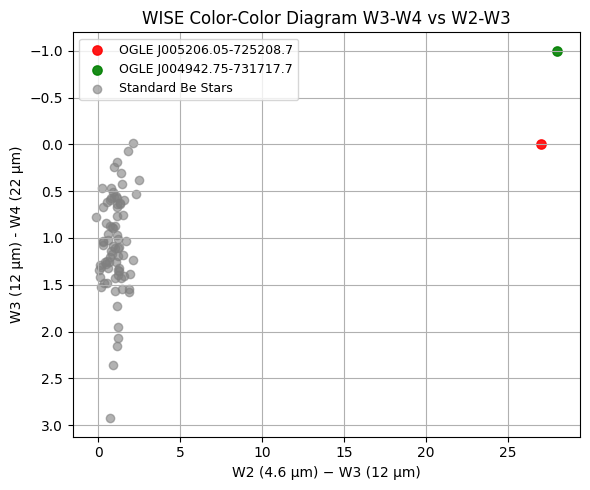

In [104]:
starsW = starsW.dropna(subset=["w1mpro", "w2m", "w3m"]).copy()

# Compute colors
starsW["W1-W2"] = starsW["w1m"] - starsW["w2m"]  # 3.4 - 4.6 μm
starsW["W2-W3"] = starsW["w2m"] - starsW["w3m"]      # 4.6 - 12 μm
starsW["W3-W4"] = starsW["w3m"] - starsW["w4m"]  
unique_stars = starsW["designation"].unique()

star_name_map = {unique_stars[0]: "OGLE J005206.05-725208.7",unique_stars[1]: "OGLE J004942.75-731717.7"}

color_map = { "OGLE J005206.05-725208.7": "red", "OGLE J004942.75-731717.7": "green"}

# ----- WISE Color–Color Diagram -----
plt.figure(figsize=(6,5))

for original_name in unique_stars:
    plot_name = star_name_map[original_name]
    subset = starsW[starsW["designation"] == original_name]
    plt.scatter(subset["W1-W2"], subset["W2-W3"],
                s=45, alpha=0.9, label=plot_name,
                color=color_map[plot_name])
    print(subset["W1-W2"], subset["W2-W3"])
plt.scatter(standardWISE["W1-W2"], standardWISE["W2-W3"],color='gray', alpha=0.6, label='Standard Be Stars')

plt.xlabel("W1 (3.4 μm) − W2 (4.6 μm)")
plt.ylabel("W2 (4.6 μm) − W3 (12 μm)")
plt.title("WISE Color–Color Diagram W1-W2 vs W2-W3")
plt.grid(True)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig('photometryWISEcol.png')

plt.show()


# ----- WISE Color–Magnitude Diagram -----
plt.figure(figsize=(6,5))

for original_name in unique_stars:
    plot_name = star_name_map[original_name]
    subset = starsW[starsW["designation"] == original_name]
    plt.scatter(subset["W2-W3"], subset["W3-W4"],
                s=45, alpha=0.9, label=plot_name,
                color=color_map[plot_name])
    print(subset["W2-W3"], subset["W3-W4"])
plt.scatter(standardWISE["W2-W3"], standardWISE["W3-W4"],color='gray', alpha=0.6, label='Standard Be Stars')
plt.xlabel("W2 (4.6 μm) − W3 (12 μm)")
plt.ylabel("W3 (12 μm) - W4 (22 μm)")
plt.title("WISE Color-Color Diagram W3-W4 vs W2-W3")
plt.gca().invert_yaxis()  # Mag axis: brighter stars higher
plt.grid(True)
plt.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig('photometryWISE34.png')
plt.show()
